<a href="https://colab.research.google.com/github/trngtina/FreqMoE-/blob/main/efficient_frontier.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# https://www.youtube.com/watch?v=AGjsvdDMyhE&list=PLPe-_ytPHqyjCSvhYWFz98k2h53rkd0dT&index=3

In [ ]:
pip install yfinance

In [ ]:
import yfinance as yf
import pandas as pd
from datetime import datetime, timedelta

tickers = ['SPY', 'BND', 'GLD']

# Calculate the date range for the last year
end_date = datetime.now()
start_date = end_date - timedelta(days=365)

# Download the data
data = yf.download(tickers, start=start_date, end=end_date)

/tmp/ipython-input-2059605744.py:12: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(tickers, start=start_date, end=end_date)
[*********************100%***********************]  3 of 3 completed


In [ ]:
# Extract close prices using .loc to handle the MultiIndex
close_prices = data.loc[:, 'Close']

# Display the first few rows of the close prices
display(close_prices.head())

Ticker,BND,GLD,SPY
Date,,,
2024-12-17,69.994995,243.940002,597.031555
2024-12-18,69.446655,239.259995,579.237915
2024-12-19,69.254265,239.600006,579.059998
2024-12-20,69.465904,242.100006,586.015137
2024-12-23,69.244644,240.960007,589.524353


In [ ]:
import numpy as np

# Calculate log returns using log normal division
log_returns = np.log(close_prices / close_prices.shift(1))

# Display the first few rows of the log returns
display(log_returns.head())

Ticker,BND,GLD,SPY
Date,,,
2024-12-17,NaN,NaN,NaN
2024-12-18,-0.007865,-0.019371,-0.030257
2024-12-19,-0.002774,0.001420,-0.000307
2024-12-20,0.003051,0.010380,0.011940
2024-12-23,-0.003190,-0.004720,0.005970


In [ ]:
# Calculate the mean of log returns for each ticker
mean_log_returns = log_returns.mean()

# Multiply by 252 for annualization, apply exp, and subtract 1
annualized_returns = np.exp(mean_log_returns * 252) - 1

# Display the annualized returns
display(annualized_returns)

,0
Ticker,
BND,0.061075
GLD,0.642597
SPY,0.138921


In [ ]:
import numpy as np

# Calculate the annualized standard deviation
annualized_std_dev = log_returns.std() * np.sqrt(252)

# Combine annualized returns and annualized standard deviation into a DataFrame
portfolio_metrics = pd.DataFrame({
    'Annualized Returns': annualized_returns,
    'Annualized Standard Deviation': annualized_std_dev
})

# Display the portfolio metrics
display(portfolio_metrics)

,Annualized Returns,Annualized Standard Deviation
Ticker,,
BND,0.061075,0.045641
GLD,0.642597,0.193234
SPY,0.138921,0.196148


In [ ]:
# Generate 3 random numbers
weights = np.random.random(3)

# Normalize them so they sum to 1
weights /= np.sum(weights)

print("Random Weights:", weights)
print("Sum of Weights:", np.sum(weights))

Random Weights: [0.33848194 0.19809646 0.46342161]
Sum of Weights: 1.0


In [ ]:
# Compute the expected return of the portfolio
portfolio_return = np.sum(weights * annualized_returns)

print("Expected Portfolio Return:", portfolio_return)

Expected Portfolio Return: 0.2123478546025661


In [ ]:
# Compute the daily covariance matrix
cov_matrix_daily = log_returns.cov()

print("Daily Covariance Matrix:")
display(cov_matrix_daily)

Daily Covariance Matrix:


Ticker,BND,GLD,SPY
Ticker,,,
BND,0.000008,0.000004,0.000004
GLD,0.000004,0.000148,0.000006
SPY,0.000004,0.000006,0.000153


In [ ]:
# Compute the annual portfolio variance
portfolio_variance = np.dot(weights.T, np.dot(cov_matrix_daily * 252, weights))

# Compute the annual portfolio standard deviation
portfolio_std_dev = np.sqrt(portfolio_variance)

print("Annual Portfolio Standard Deviation:", portfolio_std_dev)

Annual Portfolio Standard Deviation: 0.10342773351353854


In [ ]:
import yfinance as yf
from datetime import datetime, timedelta

# Ticker for the 10-year Treasury Note Yield
treasury_ticker = '^TNX'

# Download the data for the last few days to ensure we get the latest
# yfinance often returns the closing price for the previous day, so getting a small range is good
end_date = datetime.now()
start_date = end_date - timedelta(days=7) # Get data for the last week

treasury_data = yf.download(treasury_ticker, start=start_date, end=end_date)

# Get the last available closing price (yield)
current_treasury_rate = treasury_data['Close'].iloc[-1]

print(f"The current 10-year Treasury Rate (^TNX) is: {current_treasury_rate.iloc[0]}%")

/tmp/ipython-input-4183980671.py:12: FutureWarning: YF.download() has changed argument auto_adjust default to True
  treasury_data = yf.download(treasury_ticker, start=start_date, end=end_date)
[*********************100%***********************]  1 of 1 completed

The current 10-year Treasury Rate (^TNX) is: 4.147000312805176%


In [ ]:
# Convert the current treasury rate from percentage to decimal for the risk-free rate
# Assuming current_treasury_rate is a pandas Series with the rate
risk_free_rate = current_treasury_rate.iloc[0] / 100

# Compute the Sharpe Ratio
sharpe_ratio = (portfolio_return - risk_free_rate) / portfolio_std_dev

print("Portfolio Return:", portfolio_return)
print("Portfolio Standard Deviation:", portfolio_std_dev)
print("Risk-Free Rate:", risk_free_rate)
print("Sharpe Ratio:", sharpe_ratio)

Portfolio Return: 0.2123478546025661
Portfolio Standard Deviation: 0.10342773351353854
Risk-Free Rate: 0.041510000228881835
Sharpe Ratio: 1.6517605923494576


In [ ]:
def portfolio_performance(weights, risk_free_rate, annualized_returns, cov_matrix_daily):
    """
    Calculates the portfolio return, standard deviation, and Sharpe ratio.

    Args:
        weights (np.array): Array of asset weights.
        risk_free_rate (float): The risk-free rate.
        annualized_returns (pd.Series): Annualized returns for each asset.
        cov_matrix_daily (pd.DataFrame): Daily covariance matrix of asset returns.

    Returns:
        tuple: (portfolio_return, portfolio_std_dev, sharpe_ratio)
    """
    portfolio_return = np.sum(weights * annualized_returns)
    portfolio_variance = np.dot(weights.T, np.dot(cov_matrix_daily * 252, weights))
    portfolio_std_dev = np.sqrt(portfolio_variance)

    # Handle cases where std_dev might be zero to avoid division by zero
    if portfolio_std_dev == 0:
        sharpe_ratio = 0
    else:
        sharpe_ratio = (portfolio_return - risk_free_rate) / portfolio_std_dev

    return portfolio_return, portfolio_std_dev, sharpe_ratio

print("Portfolio performance function defined.")

Portfolio performance function defined.



Max Sharpe Ratio Portfolio:


,1795
Return,0.585844
Standard Deviation,0.173705
Sharpe Ratio,3.13367
Weights,"[0.005871684397018558, 0.8882300091431553, 0.1..."



Min Volatility Portfolio:


,2622
Return,0.079735
Standard Deviation,0.045072
Sharpe Ratio,0.848084
Weights,"[0.9469194689538216, 0.028843196926822707, 0.0..."


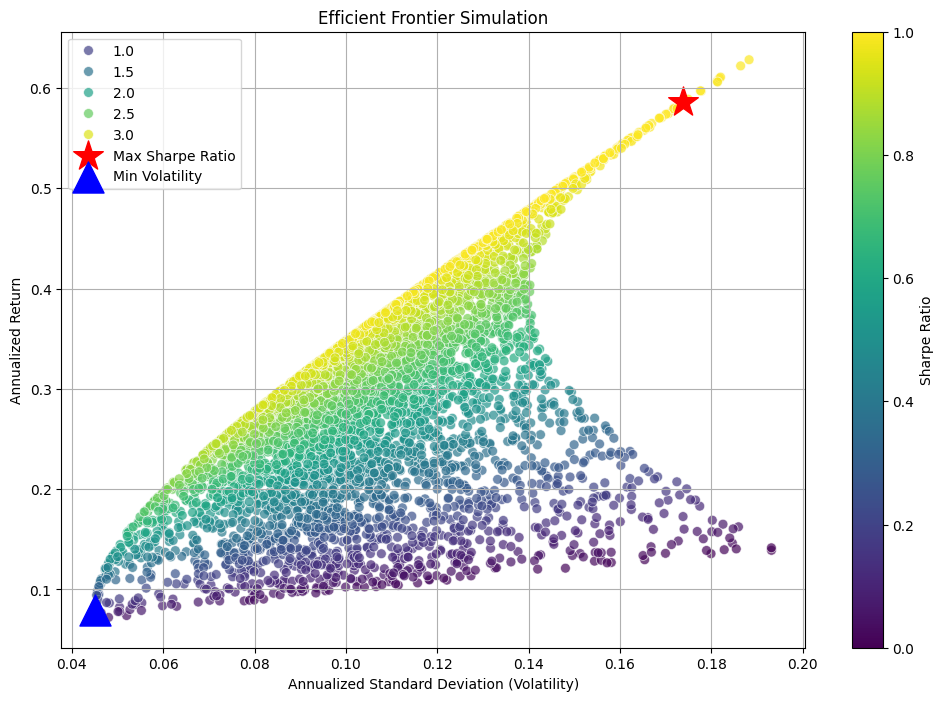

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

num_portfolios = 5000

# Initialize lists to store portfolio statistics
portfolio_returns = []
portfolio_std_devs = []
sharpe_ratios = []
portfolio_weights = []

for _ in range(num_portfolios):
    # Generate random weights
    weights = np.random.random(len(tickers))
    weights /= np.sum(weights)

    # Calculate portfolio performance
    p_return, p_std_dev, s_ratio = portfolio_performance(
        weights, risk_free_rate, annualized_returns, cov_matrix_daily
    )

    portfolio_returns.append(p_return)
    portfolio_std_devs.append(p_std_dev)
    sharpe_ratios.append(s_ratio)
    portfolio_weights.append(weights)

# Create a DataFrame for the simulation results
portfolio_results = pd.DataFrame({
    'Return': portfolio_returns,
    'Standard Deviation': portfolio_std_devs,
    'Sharpe Ratio': sharpe_ratios,
    'Weights': portfolio_weights
})

# Find the portfolio with the maximum Sharpe Ratio
max_sharpe_portfolio = portfolio_results.loc[portfolio_results['Sharpe Ratio'].idxmax()]

# Find the portfolio with the minimum Standard Deviation (minimum volatility)
min_volatility_portfolio = portfolio_results.loc[portfolio_results['Standard Deviation'].idxmin()]

print("\nMax Sharpe Ratio Portfolio:")
display(max_sharpe_portfolio)

print("\nMin Volatility Portfolio:")
display(min_volatility_portfolio)

# Plotting the Efficient Frontier
plt.figure(figsize=(12, 8))
sns.scatterplot(
    x='Standard Deviation', y='Return', hue='Sharpe Ratio', data=portfolio_results,
    palette='viridis', s=50, alpha=0.7
)

# Plot Max Sharpe Ratio portfolio
plt.scatter(
    max_sharpe_portfolio['Standard Deviation'], max_sharpe_portfolio['Return'],
    marker='*', color='red', s=500, label='Max Sharpe Ratio'
)

# Plot Min Volatility portfolio
plt.scatter(
    min_volatility_portfolio['Standard Deviation'], min_volatility_portfolio['Return'],
    marker='^', color='blue', s=500, label='Min Volatility'
)

plt.title('Efficient Frontier Simulation')
plt.xlabel('Annualized Standard Deviation (Volatility)')
plt.ylabel('Annualized Return')
plt.grid(True)
plt.legend()
plt.colorbar(label='Sharpe Ratio')
plt.show()